TASK 1: LOSS FUNCTIONS (THEORY + IMPLEMENTATION)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [9]:
# Mean Squared Error
def mse(y_pred, y_true):
    return np.mean((np.array(y_true) - np.array(y_pred)) ** 2)

# Binary Cross Entropy
def binary_crossentropy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Avoid log(0)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

    return -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )

In [10]:
y_pred = [0.2, 0.7, 0.9]
y_true = [0, 1, 1]

mse = mse(y_pred, y_true)
bcn = binary_crossentropy(y_true, y_pred)

print(f"MeanSquaredError : {mse}")
print(f"BinaryCrosEntropy : {bcn}")


MeanSquaredError : 0.04666666666666667
BinaryCrosEntropy : 0.22839300363692283


TASK 2: GRADIENT DESCENT INTUITION

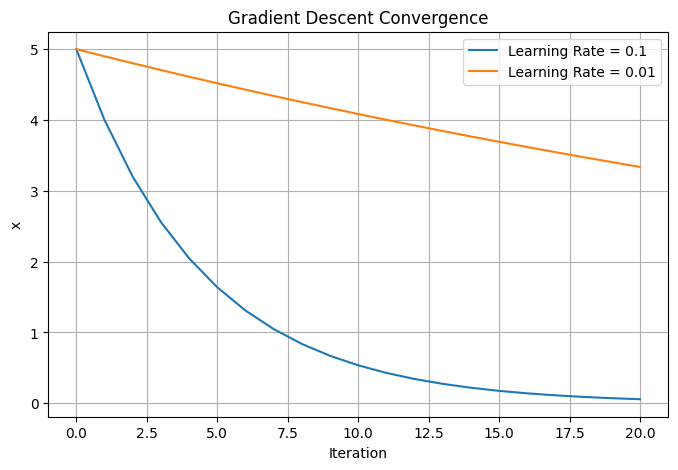

In [12]:
def fun(x):
    return x ** 2
def gradient(x):
    return 2 * x

def gradient_descent(x_init, lr, iterations):
    x = x_init
    history = [x]

    for i in range(iterations):
        x = x - lr * gradient(x)
        history.append(x)

    return history

X = 5
lr1 = 0.1
lr2 = 0.01

history1 = gradient_descent(X, lr1, 20)
history2 = gradient_descent(X, lr2, 20)

plt.figure(figsize=(8,5))
plt.plot(history1, label='Learning Rate = 0.1')
plt.plot(history2, label='Learning Rate = 0.01')

plt.title("Gradient Descent Convergence")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.grid(True)
plt.legend()

plt.show()

TASK 3: BACKPROPAGATION (MANUAL)

In [13]:
x = 2.0
y = 4.0
w = 1.0
learning_rate = 0.1

y_pred = w * x

loss = (y - y_pred) ** 2

dw = -2 * x * (y - y_pred)

new_w = w - learning_rate * dw

print("Forward Pass")
print("Predicted y =", y_pred)

print("\nLoss")
print("Loss =", loss)

print("\nGradient")
print("dw =", dw)

print("\nUpdated Weight")
print("New weight =", new_w)

Forward Pass
Predicted y = 2.0

Loss
Loss = 4.0

Gradient
dw = -8.0

Updated Weight
New weight = 1.8


In [21]:

X = tf.constant([[1.0], [2.0], [3.0]])
y = tf.constant([[2.0], [4.0], [6.0]])

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='mse'
)

history = model.fit(X, y, epochs=50, verbose=0)

print("Loss values:")
for i, loss in enumerate(history.history['loss']):
    print(f"Epoch {i+1}: {loss:.6f}")

Loss values:
Epoch 1: 19.456156
Epoch 2: 0.308828
Epoch 3: 0.076480
Epoch 4: 0.070246
Epoch 5: 0.066879
Epoch 6: 0.063702
Epoch 7: 0.060676
Epoch 8: 0.057794
Epoch 9: 0.055048
Epoch 10: 0.052433
Epoch 11: 0.049943
Epoch 12: 0.047570
Epoch 13: 0.045311
Epoch 14: 0.043159
Epoch 15: 0.041108
Epoch 16: 0.039156
Epoch 17: 0.037296
Epoch 18: 0.035524
Epoch 19: 0.033837
Epoch 20: 0.032230
Epoch 21: 0.030699
Epoch 22: 0.029240
Epoch 23: 0.027852
Epoch 24: 0.026529
Epoch 25: 0.025268
Epoch 26: 0.024068
Epoch 27: 0.022925
Epoch 28: 0.021836
Epoch 29: 0.020799
Epoch 30: 0.019811
Epoch 31: 0.018870
Epoch 32: 0.017973
Epoch 33: 0.017120
Epoch 34: 0.016306
Epoch 35: 0.015532
Epoch 36: 0.014794
Epoch 37: 0.014091
Epoch 38: 0.013422
Epoch 39: 0.012784
Epoch 40: 0.012177
Epoch 41: 0.011599
Epoch 42: 0.011048
Epoch 43: 0.010523
Epoch 44: 0.010023
Epoch 45: 0.009547
Epoch 46: 0.009094
Epoch 47: 0.008662
Epoch 48: 0.008250
Epoch 49: 0.007858
Epoch 50: 0.007485


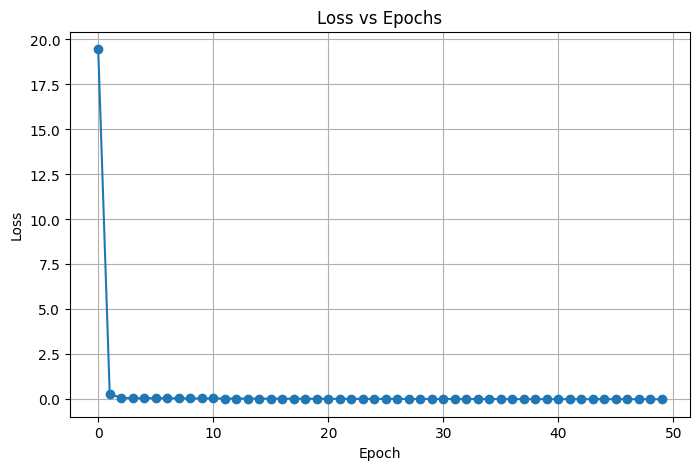

In [22]:
loss = history.history['loss']

plt.figure(figsize=(8,5))
plt.plot(loss, marker='o')
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()